# Financial Feedback Intelligence — Data Preparation Pipeline
## Banking77 Mapping · Quality Audit · Dataset Building · Label Encoding · Class Imbalance

Run each cell top to bottom. Every cell does one simple thing.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os, re, pickle
from pathlib import Path

In [54]:
# ── Load all four source files ──
bank_train = pd.read_csv("data/processed/banking77_train_clean.csv")
bank_test  = pd.read_csv("data/processed/banking77_test_clean.csv")
phrasebank = pd.read_csv("data/processed/financial_phrasebank_clean.csv")
scraped    = pd.read_csv("data/labeled/labeled_reviews.csv")

print(f"Banking77 train : {bank_train.shape}   columns: {list(bank_train.columns)}")
print(f"Banking77 test  : {bank_test.shape}   columns: {list(bank_test.columns)}")
print(f"PhraseBank      : {phrasebank.shape}   columns: {list(phrasebank.columns)}")
print(f"Scraped reviews : {scraped.shape}   columns: {list(scraped.columns)}")

Banking77 train : (9993, 3)   columns: ['text', 'label', 'label_text']
Banking77 test  : (3076, 3)   columns: ['text', 'label', 'label_text']
PhraseBank      : (4838, 2)   columns: ['label', 'text']
Scraped reviews : (12524, 17)   columns: ['source_row_id', 'source_app', 'review_text', 'star_rating', 'recorded_at', 'app_version', 'sentiment_text', 'sentiment_code', 'sentiment', 'intent', 'root_cause', 'risk_score', 'risk_band', 'recommended_action', 'cro_reasoning', 'confidence', 'normalized_text']


## Step 1 · Map Banking77 77 Intents → CRO Business Taxonomy

In [55]:
# ── Banking77 classes not relevant to mobile banking / digital wallets ──
IRRELEVANT_B77 = {
    "card_about_to_expire", "card_arrival", "card_delivery_estimate",
    "card_swallowed", "get_physical_card", "getting_spare_card",
    "order_physical_card", "card_linking",
    "atm_support", "cash_withdrawal_charge", "cash_withdrawal_not_recognised",
    "declined_cash_withdrawal", "pending_cash_withdrawal",
    "wrong_amount_of_cash_received", "top_up_by_cash_or_cheque",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "direct_debit_payment_not_recognised",
    "disposable_card_limits", "get_disposable_virtual_card", "getting_virtual_card",
    "visa_or_mastercard", "supported_cards_and_currencies",
    "fiat_currency_support", "country_support", "age_limit",
    "apple_pay_or_google_pay",
    "why_is_my_card_in_a_cooldown_period",
    "identity_document_stolen", "lost_or_stolen_phone",
}

print(f"Irrelevant classes to drop: {len(IRRELEVANT_B77)}")

Irrelevant classes to drop: 29


In [56]:
# ── Deterministic mapping: Banking77 intent → (CRO intent, CRO root cause) ──
CLEAN_MAP = {
    # Data / balance issues
    "balance_not_updated_after_bank_transfer": ("data_integrity_issue", "data_sync_issue"),
    "transfer_into_account": ("data_integrity_issue", "data_sync_issue"),
    "refund_not_showing_up": ("data_integrity_issue", "data_sync_issue"),

    # Payment failures
    "failed_transfer": ("payment_failure", "api_failure"),
    "pending_transfer": ("payment_failure", "api_failure"),
    "declined_transfer": ("payment_failure", "api_failure"),
    "cancel_transfer": ("payment_failure", "api_failure"),
    "top_up_failed": ("payment_failure", "api_failure"),
    "top_up_reverted": ("payment_failure", "api_failure"),
    "pending_top_up": ("payment_failure", "api_failure"),

    # Interbank / LankaPay
    "transfer_not_received_by_recipient": ("interbank_transfer_failure", "lankapay_ceft_failure"),

    # Refund / billing
    "request_refund": ("refund_request", "unjustified_billing"),
    "extra_charge_on_statement": ("refund_request", "unjustified_billing"),
    "transfer_fee_charged": ("refund_request", "fee_without_service"),
    "card_payment_fee_charged": ("refund_request", "fee_without_service"),

    # FX / remittance
    "exchange_rate": ("fx_conversion_complaint", "fx_rate_dispute"),
    "exchange_charge": ("fx_conversion_complaint", "fx_rate_dispute"),
    "exchange_via_app": ("fx_conversion_complaint", "fx_rate_dispute"),
    "card_payment_wrong_exchange_rate": ("fx_conversion_complaint", "fx_rate_dispute"),
    "wrong_exchange_rate_for_transfer": ("fx_conversion_complaint", "fx_rate_dispute"),

    # Access / auth
    "passcode_forgotten": ("access_blocked", "authentication_failure"),
    "pin_blocked": ("access_blocked", "authentication_failure"),
    "beneficiary_not_allowed": ("access_blocked", "device_limit_exceeded"),
    "activate_my_card": ("access_blocked", "authentication_failure"),

    # Regulatory / KYC
    "verify_my_identity": ("access_blocked", "regulatory_block"),
    "unable_to_verify_identity": ("access_blocked", "regulatory_block"),
    "verify_source_of_funds": ("regulatory_risk", "regulatory_block"),
    "verify_top_up": ("regulatory_risk", "regulatory_block"),
    "identity_document_queried": ("regulatory_risk", "regulatory_block"),

    # Security
    "lost_or_stolen_card": ("security_concern", "poor_security_implementation"),
    "compromised_card": ("security_concern", "poor_security_implementation"),

    # Technical / app broken
    "virtual_card_not_working": ("technical_failure", "app_crash_or_bug"),
    "contactless_not_working": ("technical_failure", "app_crash_or_bug"),

    # UX / friction
    "top_up_limits": ("ux_friction", "offer_discoverability"),
    "top_up_by_bank_transfer_only": ("ux_friction", "offer_discoverability"),
    "top_up_by_card_charge": ("ux_friction", "offer_discoverability"),
    "change_pin": ("ux_friction", "offer_discoverability"),
    "why_verify_identity": ("ux_friction", "offer_discoverability"),

    # Feature requests
    "automatic_top_up": ("feature_request", "offer_discoverability"),
    "edit_personal_details": ("feature_request", "offer_discoverability"),
    "receiving_money": ("feature_request", "offer_discoverability"),

    # Service quality
    "transfer_timing": ("service_quality", "slow_performance"),

    # Account closure
    "terminate_account": ("account_closure", "unresponsive_support")
}

print(f"Deterministic mappings: {len(CLEAN_MAP)} Banking77 intents")

Deterministic mappings: 43 Banking77 intents


In [57]:
# ── Combine Banking77 train + test ──
bank_all = pd.concat([bank_train, bank_test], ignore_index=True)
print(f"Banking77 combined: {len(bank_all)} rows")

# Normalize the label_text column
bank_all["b77_intent"] = (bank_all["label_text"]
    .astype(str).str.strip().str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

# Drop irrelevant classes
before = len(bank_all)
bank_all = bank_all[~bank_all["b77_intent"].isin(IRRELEVANT_B77)].copy()
print(f"Dropped {before - len(bank_all)} irrelevant rows -> {len(bank_all)} remain")

# Map each row to CRO intent and root cause
cro_intents = []
cro_root_causes = []

for i, row in bank_all.iterrows():
    b77 = row["b77_intent"]
    text = str(row["text"]).lower()

    if b77 in CLEAN_MAP:
        intent, root = CLEAN_MAP[b77]

    # ── Ambiguous intents resolved by keywords ──
    elif b77 == "card_not_working":
        if re.search(r"block|suspend|frozen|access|login|open", text):
            intent, root = "access_blocked", "authentication_failure"
        else:
            intent, root = "technical_failure", "app_crash_or_bug"

    elif b77 == "card_acceptance":
        if re.search(r"declin|reject|fail|merchant|shop|store|not accept", text):
            intent, root = "payment_failure", "api_failure"
        else:
            intent, root = "ux_friction", "offer_discoverability"

    elif b77 == "card_payment_not_recognised":
        if re.search(r"refund|money back|charge|reverse|didn.t make|unauthori", text):
            intent, root = "refund_request", "unjustified_billing"
        else:
            intent, root = "data_integrity_issue", "data_sync_issue"

    elif b77 == "pending_card_payment":
        if re.search(r"day|week|long|still|never|wrong", text):
            intent, root = "data_integrity_issue", "data_sync_issue"
        else:
            intent, root = "payment_failure", "api_failure"

    elif b77 == "declined_card_payment":
        if re.search(r"block|suspend|fraud|unauthori|security", text):
            intent, root = "access_blocked", "regulatory_block"
        else:
            intent, root = "payment_failure", "api_failure"

    elif b77 == "reverted_card_payment?":
        if re.search(r"refund|want|please|return|back", text):
            intent, root = "refund_request", "unjustified_billing"
        else:
            intent, root = "data_integrity_issue", "data_sync_issue"

    else:
        # Unmapped intent -> noise
        intent, root = "noise", "unreadable_text"

    cro_intents.append(intent)
    cro_root_causes.append(root)

bank_all["cro_intent"] = cro_intents
bank_all["cro_root_cause"] = cro_root_causes

print(f"\nMapped CRO intent distribution (Banking77):")
print(bank_all["cro_intent"].value_counts().to_string())

Banking77 combined: 13069 rows
Dropped 4615 irrelevant rows -> 8454 remain

Mapped CRO intent distribution (Banking77):
cro_intent
payment_failure               1602
refund_request                 981
access_blocked                 980
data_integrity_issue           936
noise                          712
ux_friction                    705
fx_conversion_complaint        677
feature_request                463
regulatory_risk                319
technical_failure              305
security_concern               248
interbank_transfer_failure     210
service_quality                168
account_closure                148


In [58]:
# ── Save mapped Banking77 ──
bank_all[["text", "b77_intent", "cro_intent", "cro_root_cause"]].to_csv(
    "data/processed/banking77_mapped.csv", index=False
)
print(f"Saved data/processed/banking77_mapped.csv ({len(bank_all)} rows)")

Saved data/processed/banking77_mapped.csv (8454 rows)


## Step 2 · Scraped Review Quality Audit

In [59]:
# ── Scraped review summary ──
print(f"Scraped reviews: {scraped.shape}")
print(f"Text column: 'review_text'")
print(f"Unique sentiments: {scraped['sentiment'].nunique()}")
print(f"Unique intents: {scraped['intent'].nunique()}")
print(f"Unique root causes: {scraped['root_cause'].nunique()}")
print(f"Rows with risk_score: {scraped['risk_score'].notna().sum()}")

Scraped reviews: (12524, 17)
Text column: 'review_text'
Unique sentiments: 4
Unique intents: 18
Unique root causes: 26
Rows with risk_score: 12524


In [60]:
# ── Label value counts ──
for col_name in ["sentiment", "intent", "root_cause", "risk_band"]:
    print(f"SCRAPED — {col_name.upper()}")
    if col_name in scraped.columns:
        print(scraped[col_name].value_counts())
    else:
        print(f"  Column '{col_name}' not found")
    print()

SCRAPED — SENTIMENT
sentiment
negative    7032
positive    3748
mixed       1238
neutral      506
Name: count, dtype: int64

SCRAPED — INTENT
intent
complaint                     4615
praise                        3641
technical_failure             1361
feature_request               1041
access_blocked                 325
ux_friction                    265
security_concern               193
noise                          164
competitor_switch              145
payment_failure                145
support_failure                144
churn_signal                   111
service_quality                110
data_integrity_issue           108
refund_request                  94
account_closure                 45
regulatory_risk                 14
interbank_transfer_failure       3
Name: count, dtype: int64

SCRAPED — ROOT_CAUSE
root_cause
general_satisfaction             3513
app_crash_or_bug                 1975
offer_discoverability            1165
authentication_failure           1113
security_r

In [61]:
# ── Null / blank / placeholder check ──
label_cols = ["sentiment", "intent", "root_cause"]
bad_values = ["unknown", "Unknown", "UNKNOWN", "", "nan", "none", "None", "NaN"]

total_bad = 0
for col in label_cols:
    n_null = scraped[col].isna().sum()
    n_bad  = scraped[col].isin(bad_values).sum()
    total_bad += n_null + n_bad
    status = "OK" if (n_null + n_bad) == 0 else "ISSUE"
    print(f"  {status}  {col:15s}  null={n_null}  bad_string={n_bad}")

print()
if total_bad == 0:
    print("No unknown or blank labels found")
else:
    print(f"Total bad labels: {total_bad} — review needed")

  OK  sentiment        null=0  bad_string=0
  OK  intent           null=0  bad_string=0
  OK  root_cause       null=0  bad_string=0

No unknown or blank labels found


In [62]:
# ── Spot-check noise, other, and low-confidence rows ──
noise_df = scraped[scraped["intent"] == "noise"]
print(f"intent == 'noise': {len(noise_df)} rows")
if len(noise_df) > 0:
    display(noise_df[["review_text", "sentiment", "root_cause", "risk_score"]].head(10))

print()
other_rc = scraped[scraped["root_cause"] == "other"]
print(f"root_cause == 'other': {len(other_rc)} rows")
if len(other_rc) > 0:
    display(other_rc[["review_text", "sentiment", "intent", "risk_score"]].head(10))

print()
if "confidence" in scraped.columns:
    low_conf = scraped[scraped["confidence"] < 0.6]
    print(f"confidence < 0.6: {len(low_conf)} rows (manual review recommended)")
    if len(low_conf) > 0:
        display(low_conf[["review_text", "intent", "root_cause", "confidence"]].head(10))

intent == 'noise': 164 rows


,review_text,sentiment,root_cause,risk_score
43,Touch and hold a clip and I you can get it don...,neutral,unreadable_text,0
71,mama awurudu gaanak frimi pavichchi karanawaa ...,negative,unreadable_text,0
80,me meken salli hoyanna puluwanda 🙏🙏,positive,unreadable_text,0
96,smart fo tha yang pipals,neutral,unreadable_text,0
98,I have no experience with this.,neutral,unreadable_text,0
133,Frimi kiyanne itin aye wenama lokayak 😁🤘☕,positive,unreadable_text,0
150,Some one is tell me nation trust is good. What...,neutral,unreadable_text,0
174,Just look at app like paypal trust the technol...,negative,unreadable_text,0
182,s. Zzz w kisses was aww ßw assess AA Z,neutral,unreadable_text,0
225,Mona magulak da e update eka,neutral,unreadable_text,0



root_cause == 'other': 295 rows


,review_text,sentiment,intent,risk_score
21,Atm card සහා virtual card එකේ amount limit adj...,neutral,feature_request,4
108,Keep asking default wallet app preferences eac...,negative,complaint,6
113,Can anyone tell me I can't use NFC tap to pay ...,negative,complaint,5
180,NFC payment option removed from update. Then u...,negative,complaint,8
198,I don't have any good experience with this app,negative,complaint,5
217,New update is not user friendly. For some reas...,negative,complaint,8
219,new update is the worst!! not user friendly at...,negative,complaint,8
221,"App UI looks good, however when oprning the ap...",mixed,complaint,5
277,Don't use this app..it's wasting your time and...,negative,complaint,6
386,"Disappointed with new update, useless",negative,complaint,5



confidence < 0.6: 155 rows (manual review recommended)


,review_text,intent,root_cause,confidence
43,Touch and hold a clip and I you can get it don...,noise,unreadable_text,0.5
71,mama awurudu gaanak frimi pavichchi karanawaa ...,noise,unreadable_text,0.5
133,Frimi kiyanne itin aye wenama lokayak 😁🤘☕,noise,unreadable_text,0.5
150,Some one is tell me nation trust is good. What...,noise,unreadable_text,0.4
174,Just look at app like paypal trust the technol...,noise,unreadable_text,0.4
374,"Not working f****** b****** ,2022 /10 /25Tried...",noise,unreadable_text,0.5
386,"Disappointed with new update, useless",complaint,other,0.5
387,Trying to install this App for future use,noise,unreadable_text,0.2
573,Supiri app eka oyath adama රෙජිස්ට්‍රාර් wenna,noise,unreadable_text,0.5
630,Unhappy about the top up condition,complaint,general_satisfaction,0.5


In [63]:
# Remove noise rows from intent
scraped = scraped[scraped["intent"] != "noise"].copy()

# Remove generic/unclear root cause rows
scraped = scraped[scraped["root_cause"] != "other"].copy()

# Remove low-confidence rows if confidence column exists
if "confidence" in scraped.columns:
    scraped = scraped[scraped["confidence"] >= 0.6].copy()

print("After cleanup:", scraped.shape)

After cleanup: (12028, 17)


In [64]:
# ── High-risk complaints ──
high_risk = scraped[(scraped["intent"] == "complaint") & (scraped["risk_score"] >= 7)]
print(f"complaint + risk_score >= 7: {len(high_risk)} rows")
if len(high_risk) > 0:
    display(high_risk[["review_text", "sentiment", "root_cause", "risk_score", "risk_band"]].head(10))

complaint + risk_score >= 7: 3902 rows


,review_text,sentiment,root_cause,risk_score,risk_band
0,Still locked out of the app after 3 days! 😩 I'...,negative,notification_delivery_failure,8,HIGH
1,"Can't create new account. Showing ""run time er...",negative,app_crash_or_bug,7,HIGH
2,"First impression ""A big Run time ERROR""",negative,app_crash_or_bug,7,HIGH
3,poor customer hotline service in an emergency ...,negative,unresponsive_support,8,HIGH
4,I cant create an account. I tried different de...,negative,app_crash_or_bug,7,HIGH
5,i tried to create a new account but it's alway...,negative,api_failure,7,HIGH
6,Call centre never answers your call. Waste of ...,negative,unresponsive_support,9,CRITICAL
7,I can't go past the Sign Up section which give...,negative,app_crash_or_bug,7,HIGH
9,not letting me create an account. showing netw...,negative,unresponsive_support,9,CRITICAL
10,Cannot even create an account. The app keeps t...,negative,app_crash_or_bug,8,HIGH


## Step 3 · Build Four Datasets

In [79]:
# ── Build Sentiment Dataset (PhraseBank + Scraped) ──

# PhraseBank: columns are ['label', 'text']
pb_sent = phrasebank[["text", "label"]].copy()
pb_sent.columns = ["text", "sentiment"]
pb_sent["sentiment"] = pb_sent["sentiment"].str.lower().str.strip()

# Scraped: text column is 'review_text'
sc_sent = scraped[["review_text", "sentiment"]].copy()
sc_sent.columns = ["text", "sentiment"]

# Combine, clean, deduplicate
sentiment_df = pd.concat([pb_sent, sc_sent], ignore_index=True)
sentiment_df = sentiment_df.dropna(subset=["text", "sentiment"])
sentiment_df = sentiment_df.drop_duplicates(subset=["text"])
sentiment_df["text"] = sentiment_df["text"].str.strip()
sentiment_df = sentiment_df[sentiment_df["text"].str.len() > 3]

print(f"Sentiment dataset: {sentiment_df.shape}")
print(sentiment_df["sentiment"].value_counts())

Sentiment dataset: (15975, 2)
sentiment
negative    6738
positive    4897
neutral     3208
mixed       1132
Name: count, dtype: int64


In [66]:
# ── Build Intent Dataset (MAPPED Banking77 + Scraped) ──
# IMPORTANT: Use the CRO-mapped Banking77 intents, NOT the raw 77 classes

# Banking77: use cro_intent column from the mapping step above
b77_int = bank_all[["text", "cro_intent"]].copy()
b77_int.columns = ["text", "intent"]

# Scraped: text column is 'review_text'
sc_int = scraped[["review_text", "intent"]].copy()
sc_int.columns = ["text", "intent"]

# Combine, clean, deduplicate
intent_df = pd.concat([b77_int, sc_int], ignore_index=True)
intent_df = intent_df.dropna(subset=["text", "intent"])
intent_df = intent_df.drop_duplicates(subset=["text"])
intent_df["text"] = intent_df["text"].str.strip()
intent_df = intent_df[intent_df["text"].str.len() > 3]

print(f"Intent dataset: {intent_df.shape}")
print(f"Number of classes: {intent_df['intent'].nunique()}")
print(intent_df["intent"].value_counts())

Intent dataset: (19586, 2)
Number of classes: 19
intent
complaint                     4355
praise                        3433
payment_failure               1698
feature_request               1438
technical_failure             1333
access_blocked                1227
refund_request                1055
data_integrity_issue           988
ux_friction                    911
noise                          712
fx_conversion_complaint        677
security_concern               407
regulatory_risk                328
service_quality                251
interbank_transfer_failure     212
account_closure                192
competitor_switch              138
support_failure                127
churn_signal                   104
Name: count, dtype: int64


In [67]:
# ── Build Root Cause Dataset (Scraped only) ──
rc_df = scraped[["review_text", "root_cause"]].copy()
rc_df.columns = ["text", "root_cause"]
rc_df = rc_df.dropna(subset=["text", "root_cause"])
rc_df = rc_df.drop_duplicates(subset=["text"])
rc_df["text"] = rc_df["text"].str.strip()
rc_df = rc_df[rc_df["text"].str.len() > 3]

print(f"Root cause dataset: {rc_df.shape}")
print(rc_df["root_cause"].value_counts())

Root cause dataset: (11137, 2)
root_cause
general_satisfaction             3313
app_crash_or_bug                 1815
offer_discoverability            1093
authentication_failure           1055
security_restriction_ux           578
slow_performance                  471
competitor_reference              424
unjustified_billing               422
unresponsive_support              381
app_update_regression             368
notification_delivery_failure     279
api_failure                       278
data_sync_issue                   216
financial_safety_confidence       160
poor_security_implementation      131
device_limit_exceeded              83
biometric_failure                  36
otp_loop_failure                   10
account_freeze_no_reason            7
regulatory_block                    5
lankapay_ceft_failure               4
qr_payment_failure                  3
unreadable_text                     2
misleading_promotion                2
fee_without_service                 1
Name: co

In [68]:
# ── Build Risk Dataset (Scraped only) ──
risk_df = scraped[["review_text", "risk_score", "risk_band"]].copy()
risk_df.columns = ["text", "risk_score", "risk_band"]
risk_df = risk_df.dropna(subset=["text", "risk_score"])
risk_df = risk_df.drop_duplicates(subset=["text"])
risk_df["text"] = risk_df["text"].str.strip()
risk_df["risk_score"] = pd.to_numeric(risk_df["risk_score"], errors="coerce")
risk_df = risk_df.dropna(subset=["risk_score"])
risk_df = risk_df[risk_df["text"].str.len() > 3]

# Encode risk_band into risk_label integer
risk_band_order = ["NEGLIGIBLE", "LOW", "MODERATE", "HIGH", "CRITICAL"]
risk_df["risk_band"] = risk_df["risk_band"].str.upper().str.strip()
risk_df["risk_label"] = pd.Categorical(
    risk_df["risk_band"], categories=risk_band_order, ordered=True
).codes.astype(int)

if (risk_df["risk_label"] < 0).any():
    print("WARNING: Unknown risk_band values found!")
    print(risk_df[risk_df["risk_label"] < 0]["risk_band"].unique())
else:
    print("All risk_band values are valid")

print(f"\nRisk dataset: {risk_df.shape}")
print(f"Columns: {list(risk_df.columns)}")
print(risk_df["risk_band"].value_counts())

All risk_band values are valid

Risk dataset: (11137, 4)
Columns: ['text', 'risk_score', 'risk_band', 'risk_label']
risk_band
HIGH          4385
NEGLIGIBLE    3459
LOW           1156
CRITICAL      1122
MODERATE      1015
Name: count, dtype: int64


In [69]:
# ── Save all four datasets ──
OUT = "data/model_ready"
Path(OUT).mkdir(parents=True, exist_ok=True)

sentiment_df.to_csv(f"{OUT}/sentiment_dataset.csv", index=False)
intent_df.to_csv(f"{OUT}/intent_dataset.csv", index=False)
rc_df.to_csv(f"{OUT}/root_cause_dataset.csv", index=False)
risk_df.to_csv(f"{OUT}/risk_dataset.csv", index=False)

print(f"sentiment_dataset.csv  : {sentiment_df.shape}")
print(f"intent_dataset.csv     : {intent_df.shape}")
print(f"root_cause_dataset.csv : {rc_df.shape}")
print(f"risk_dataset.csv       : {risk_df.shape}")
print(f"\nAll saved to {OUT}/")

sentiment_dataset.csv  : (15975, 2)
intent_dataset.csv     : (19586, 2)
root_cause_dataset.csv : (11137, 2)
risk_dataset.csv       : (11137, 4)

All saved to data/model_ready/


## Step 4 · Label Encoding

In [70]:
# ── Sentiment label encoding ──
le_sentiment = LabelEncoder()
sentiment_df["sentiment_label"] = le_sentiment.fit_transform(sentiment_df["sentiment"])

print("Sentiment encoding:")
for idx, label in enumerate(le_sentiment.classes_):
    count = (sentiment_df["sentiment"] == label).sum()
    print(f"  {idx}  <-  {label:12s}  ({count} rows)")

Sentiment encoding:
  0  <-  mixed         (1132 rows)
  1  <-  negative      (6738 rows)
  2  <-  neutral       (3208 rows)
  3  <-  positive      (4897 rows)


In [71]:
# ── Intent label encoding ──
le_intent = LabelEncoder()
intent_df["intent_label"] = le_intent.fit_transform(intent_df["intent"])

print("Intent encoding:")
for idx, label in enumerate(le_intent.classes_):
    count = (intent_df["intent"] == label).sum()
    print(f"  {idx:2d}  <-  {label:30s}  ({count} rows)")

Intent encoding:
   0  <-  access_blocked                  (1227 rows)
   1  <-  account_closure                 (192 rows)
   2  <-  churn_signal                    (104 rows)
   3  <-  competitor_switch               (138 rows)
   4  <-  complaint                       (4355 rows)
   5  <-  data_integrity_issue            (988 rows)
   6  <-  feature_request                 (1438 rows)
   7  <-  fx_conversion_complaint         (677 rows)
   8  <-  interbank_transfer_failure      (212 rows)
   9  <-  noise                           (712 rows)
  10  <-  payment_failure                 (1698 rows)
  11  <-  praise                          (3433 rows)
  12  <-  refund_request                  (1055 rows)
  13  <-  regulatory_risk                 (328 rows)
  14  <-  security_concern                (407 rows)
  15  <-  service_quality                 (251 rows)
  16  <-  support_failure                 (127 rows)
  17  <-  technical_failure               (1333 rows)
  18  <-  ux_friction 

In [72]:
# ── Root cause label encoding ──
le_root_cause = LabelEncoder()
rc_df["root_cause_label"] = le_root_cause.fit_transform(rc_df["root_cause"])

print("Root cause encoding:")
for idx, label in enumerate(le_root_cause.classes_):
    count = (rc_df["root_cause"] == label).sum()
    print(f"  {idx:2d}  <-  {label:35s}  ({count} rows)")

Root cause encoding:
   0  <-  account_freeze_no_reason             (7 rows)
   1  <-  api_failure                          (278 rows)
   2  <-  app_crash_or_bug                     (1815 rows)
   3  <-  app_update_regression                (368 rows)
   4  <-  authentication_failure               (1055 rows)
   5  <-  biometric_failure                    (36 rows)
   6  <-  competitor_reference                 (424 rows)
   7  <-  data_sync_issue                      (216 rows)
   8  <-  device_limit_exceeded                (83 rows)
   9  <-  fee_without_service                  (1 rows)
  10  <-  financial_safety_confidence          (160 rows)
  11  <-  general_satisfaction                 (3313 rows)
  12  <-  lankapay_ceft_failure                (4 rows)
  13  <-  misleading_promotion                 (2 rows)
  14  <-  notification_delivery_failure        (279 rows)
  15  <-  offer_discoverability                (1093 rows)
  16  <-  otp_loop_failure                     (10 rows)


In [73]:
# ── Save label encoders and encoded CSVs ──
enc_dir = f"{OUT}/encoders"
Path(enc_dir).mkdir(exist_ok=True)

for name, enc in [("sentiment", le_sentiment), ("intent", le_intent), ("root_cause", le_root_cause)]:
    with open(f"{enc_dir}/le_{name}.pkl", "wb") as f:
        pickle.dump(enc, f)
    print(f"  le_{name}.pkl saved ({len(enc.classes_)} classes)")

sentiment_df.to_csv(f"{OUT}/sentiment_encoded.csv", index=False)
intent_df.to_csv(f"{OUT}/intent_encoded.csv", index=False)
rc_df.to_csv(f"{OUT}/root_cause_encoded.csv", index=False)

print("\nEncoded CSVs saved to", OUT)

  le_sentiment.pkl saved (4 classes)
  le_intent.pkl saved (19 classes)
  le_root_cause.pkl saved (25 classes)

Encoded CSVs saved to data/model_ready


## Step 5 · Class Imbalance Analysis

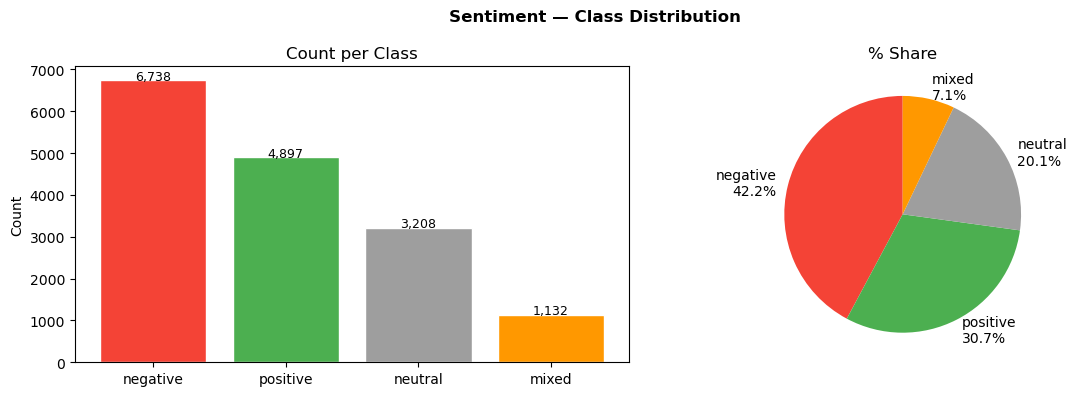

Imbalance ratio: 6.0x
Severe imbalance — use class weights


In [74]:
# ── Sentiment imbalance ──
vc = sentiment_df["sentiment"].value_counts()
pct = (vc / vc.sum() * 100).round(1)
cols = {"positive": "#4CAF50", "negative": "#F44336", "neutral": "#9E9E9E", "mixed": "#FF9800"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Sentiment — Class Distribution", fontweight="bold")

ax = axes[0]
bars = ax.bar(vc.index, vc.values, color=[cols.get(c, "#888") for c in vc.index], edgecolor="white")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f"{val:,}", ha="center", fontsize=9)
ax.set_title("Count per Class")
ax.set_ylabel("Count")

ax = axes[1]
ax.pie(vc.values, labels=[f"{l}\n{p}%" for l, p in zip(vc.index, pct)],
       colors=[cols.get(c, "#888") for c in vc.index], startangle=90)
ax.set_title("% Share")

plt.tight_layout()
plt.savefig(f"{OUT}/imbalance_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = vc.max() / vc.min()
print(f"Imbalance ratio: {ratio:.1f}x")
if ratio > 5:
    print("Severe imbalance — use class weights")

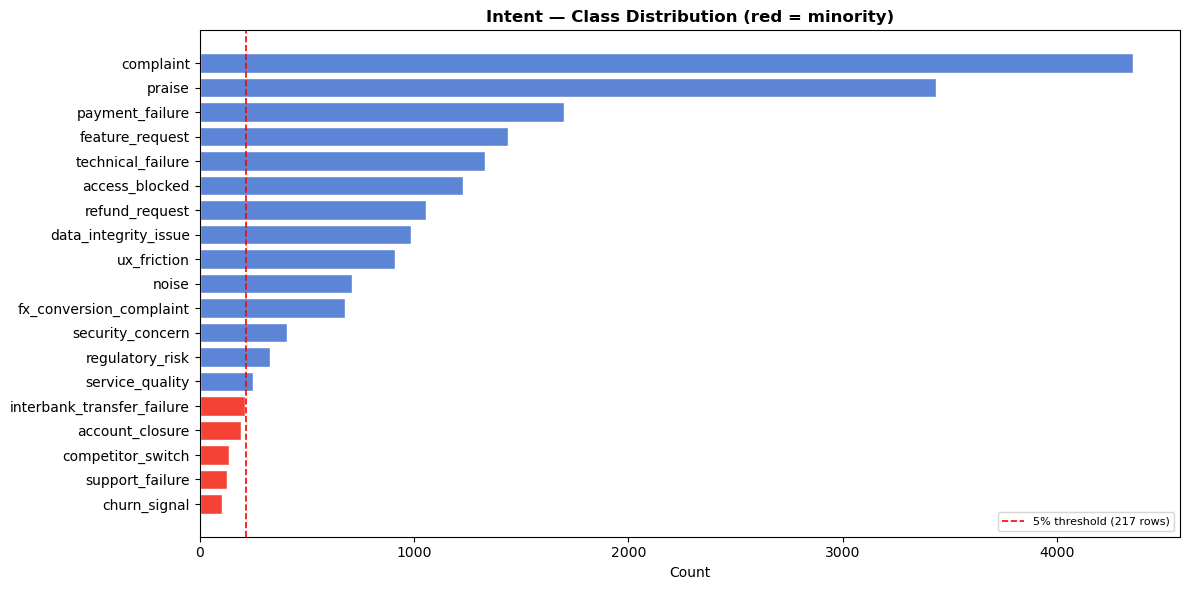

Imbalance ratio: 41.9x
Classes below 5% threshold: 5


In [75]:
# ── Intent imbalance ──
vc2 = intent_df["intent"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
threshold = vc2.max() * 0.05
bar_cols = ["#F44336" if v < threshold else "#5C85D6" for v in vc2.values]
ax.barh(vc2.index, vc2.values, color=bar_cols, edgecolor="white")
ax.axvline(threshold, color="red", linestyle="--", lw=1.2, label=f"5% threshold ({int(threshold)} rows)")
ax.set_title("Intent — Class Distribution (red = minority)", fontweight="bold")
ax.set_xlabel("Count")
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{OUT}/imbalance_intent.png", dpi=150, bbox_inches="tight")
plt.show()

ratio2 = vc2.max() / vc2.min()
print(f"Imbalance ratio: {ratio2:.1f}x")
print(f"Classes below 5% threshold: {(vc2 < threshold).sum()}")

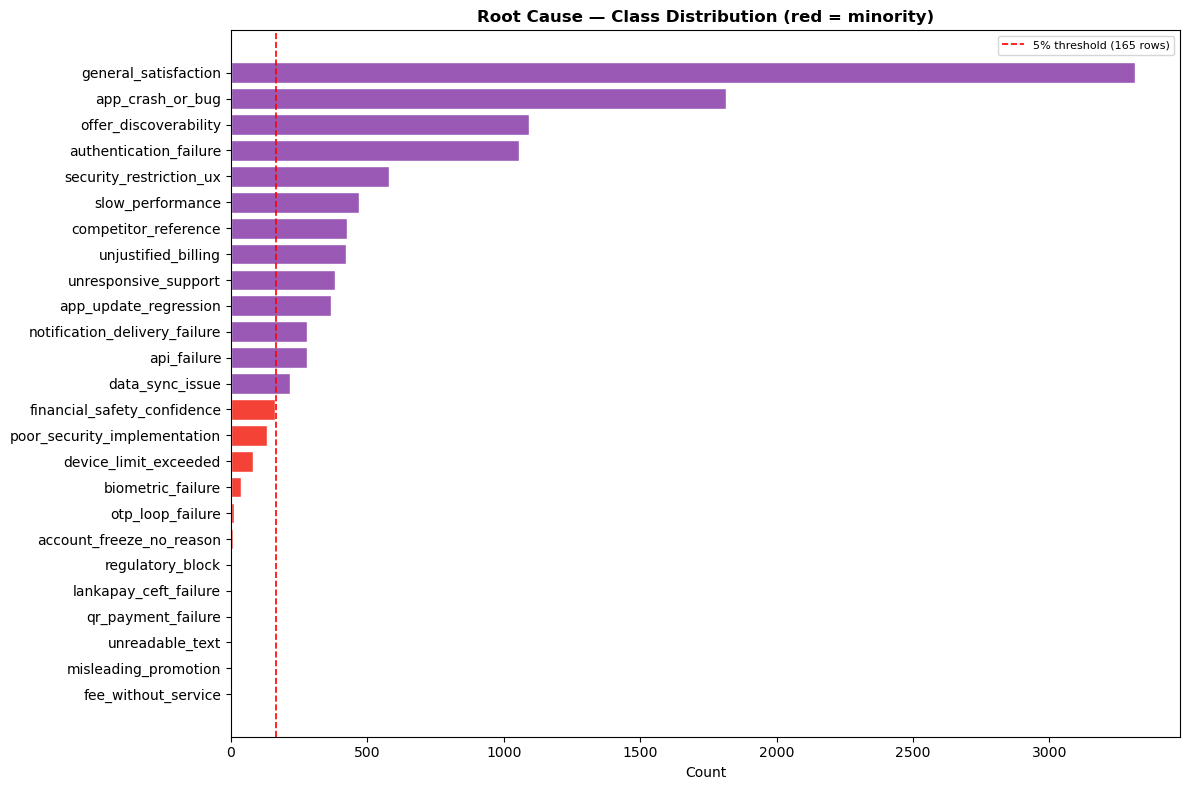

Imbalance ratio: 3313.0x
Classes with < 50 samples: 9
root_cause
biometric_failure           36
otp_loop_failure            10
account_freeze_no_reason     7
regulatory_block             5
lankapay_ceft_failure        4
qr_payment_failure           3
unreadable_text              2
misleading_promotion         2
fee_without_service          1


In [76]:
# ── Root cause imbalance ──
vc3 = rc_df["root_cause"].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
threshold3 = vc3.max() * 0.05
bar_cols3 = ["#F44336" if v < threshold3 else "#9B59B6" for v in vc3.values]
ax.barh(vc3.index, vc3.values, color=bar_cols3, edgecolor="white")
ax.axvline(threshold3, color="red", linestyle="--", lw=1.2, label=f"5% threshold ({int(threshold3)} rows)")
ax.set_title("Root Cause — Class Distribution (red = minority)", fontweight="bold")
ax.set_xlabel("Count")
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{OUT}/imbalance_root_cause.png", dpi=150, bbox_inches="tight")
plt.show()

ratio3 = vc3.max() / vc3.min()
print(f"Imbalance ratio: {ratio3:.1f}x")
print(f"Classes with < 50 samples: {(vc3 < 50).sum()}")
if (vc3 < 50).sum() > 0:
    print(vc3[vc3 < 50].to_string())

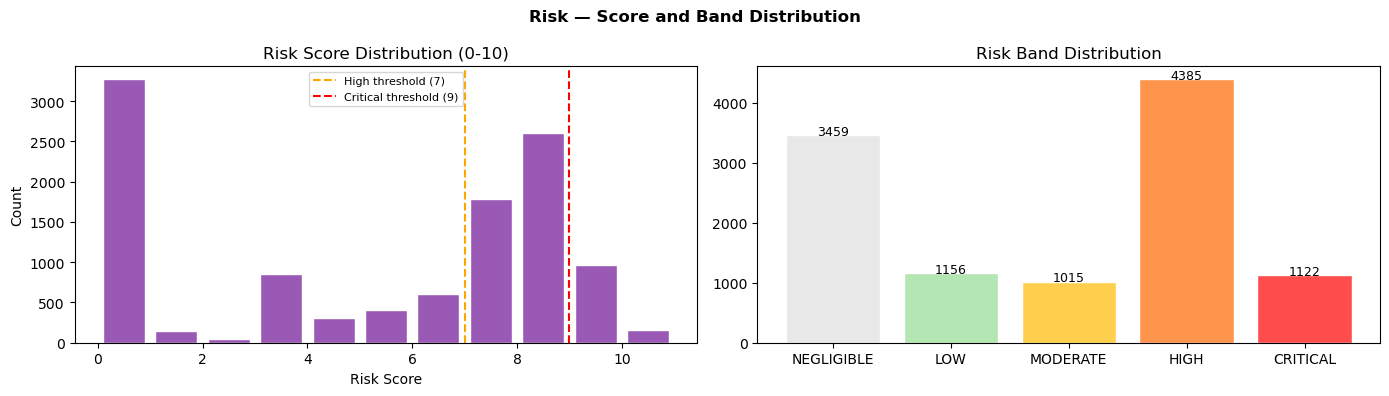

Risk band distribution:
  NEGLIGIBLE   :  3459  (31.1%)
  LOW          :  1156  (10.4%)
  MODERATE     :  1015  (9.1%)
  HIGH         :  4385  (39.4%)
  CRITICAL     :  1122  (10.1%)


In [77]:
# ── Risk band imbalance ──
band_order = ["NEGLIGIBLE", "LOW", "MODERATE", "HIGH", "CRITICAL"]
band_cols = {"NEGLIGIBLE": "#e8e8e8", "LOW": "#b3e6b3", "MODERATE": "#ffd04d",
             "HIGH": "#ff944d", "CRITICAL": "#ff4d4d"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Risk — Score and Band Distribution", fontweight="bold")

ax = axes[0]
ax.hist(risk_df["risk_score"], bins=range(0, 12), color="#9B59B6", edgecolor="white", rwidth=0.8)
ax.axvline(7, color="orange", linestyle="--", lw=1.5, label="High threshold (7)")
ax.axvline(9, color="red", linestyle="--", lw=1.5, label="Critical threshold (9)")
ax.set_title("Risk Score Distribution (0-10)")
ax.set_xlabel("Risk Score")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

ax = axes[1]
vc4 = risk_df["risk_band"].value_counts().reindex(band_order, fill_value=0)
ax.bar(vc4.index, vc4.values, color=[band_cols.get(b, "#888") for b in vc4.index], edgecolor="white")
for i, (k, v) in enumerate(vc4.items()):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)
ax.set_title("Risk Band Distribution")

plt.tight_layout()
plt.savefig(f"{OUT}/imbalance_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print("Risk band distribution:")
for band, cnt in vc4.items():
    pct_val = cnt / vc4.sum() * 100
    print(f"  {band:12s} : {cnt:5d}  ({pct_val:.1f}%)")

In [78]:
# ── Final Summary ──
print(f"Sentiment  : {sentiment_df.shape[0]:>6,} rows, {sentiment_df['sentiment'].nunique()} classes")
print(f"Intent     : {intent_df.shape[0]:>6,} rows, {intent_df['intent'].nunique()} classes")
print(f"Root Cause : {rc_df.shape[0]:>6,} rows, {rc_df['root_cause'].nunique()} classes")
print(f"Risk       : {risk_df.shape[0]:>6,} rows, {risk_df['risk_band'].nunique()} bands")


Sentiment  : 15,975 rows, 4 classes
Intent     : 19,586 rows, 19 classes
Root Cause : 11,137 rows, 25 classes
Risk       : 11,137 rows, 5 bands
